<a href="https://colab.research.google.com/github/hania-sajjad/Week-2-Task/blob/main/week2_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#IMPORT LIBRARIES
# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")
# Display plots within the notebook
%matplotlib inline
# Improve plot appearance
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
#UPLOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#LOAD DATASET
file_path = "/content/drive/MyDrive/Week2Data/Steel_industry_data.csv"
df = pd.read_csv(file_path)
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Examine Dataset Dimensions

The shape of the dataset is checked to determine the total number of rows and columns. This provides a quick overview of the dataset size before performing further analysis.

In [ ]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 35040
Number of Columns: 11


## Dataset Structure

The structure of the dataset is examined using the `info()` function. This provides information about each column, including data types, number of non-null values, and memory usage. Understanding the dataset structure helps identify potential issues such as missing values or incorrect data types before analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

## Statistical Summary

Descriptive statistics are generated for all numerical features. This includes measures such as count, mean, standard deviation, minimum, maximum, and quartiles, providing a better understanding of the data distribution.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2(tCO2),35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
NSM,35040.0,42750.000000,24940.534317,0.0,21375.00,42750.00,64125.0000,85500.00


## Missing Value Analysis

Missing values are identified to evaluate the completeness of the dataset. Detecting missing values is an essential step before feature engineering and model training because incomplete data may affect model performance.

In [ ]:
missing = df.isnull().sum()

print(missing)

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


## Duplicate Record Detection

Duplicate records are identified to ensure data quality. Duplicate observations may introduce bias during analysis and model training if not handled appropriately.

In [ ]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## Data Types

The data types of all columns are displayed to verify whether each feature has been assigned the appropriate format (e.g., numerical, categorical, or datetime). This information is particularly important before performing feature engineering.

In [ ]:
df.dtypes

,0
date,object
Usage_kWh,float64
Lagging_Current_Reactive.Power_kVarh,float64
Leading_Current_Reactive_Power_kVarh,float64
CO2(tCO2),float64
Lagging_Current_Power_Factor,float64
Leading_Current_Power_Factor,float64
NSM,int64
WeekStatus,object
Day_of_week,object


## Inspect the Date Column

Before extracting time-based features, we examine the date column to determine whether it contains both the date and time information required for feature engineering.

In [ ]:
#GET EXACT COLUMN NAMES
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

In [ ]:
df['date'].head()
#Convert
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['date'].dtype

dtype('<M8[ns]')

## Feature Engineering from the Date Column

To capture temporal patterns in energy consumption, new features are extracted from the `date` column. These include the hour of the day, day of the week, month, and an indicator showing whether the observation falls on a weekday or weekend. These engineered features may improve the performance of machine learning models by providing additional information about time-related trends.

In [ ]:
#Extract hour of the day
df['Hour'] = df['date'].dt.hour

#Extract day name
df['Day_Name'] = df['date'].dt.day_name()

#Extract month number
df['Month'] = df['date'].dt.month

#Determine whether the day is a weekday or weekend
df['Day_Type'] = np.where(df['date'].dt.weekday < 5, 'Weekday', 'Weekend')

#Display the new columns
df[['date', 'Hour', 'Day_Name', 'Month', 'Day_Type']].head()

,date,Hour,Day_Name,Month,Day_Type
0,2018-01-01 00:15:00,0,Monday,1,Weekday
1,2018-01-01 00:30:00,0,Monday,1,Weekday
2,2018-01-01 00:45:00,0,Monday,1,Weekday
3,2018-01-01 01:00:00,1,Monday,1,Weekday
4,2018-01-01 01:15:00,1,Monday,1,Weekday


## Create Power Factor Ratio

A new feature called **Power_Factor_Ratio** is created by dividing the leading current power factor by the lagging current power factor.

This engineered feature captures the relationship between the two power factor measurements and may provide additional information for predicting energy consumption.

In [ ]:
#Create Power Factor Ratio
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor']
    / df['Lagging_Current_Power_Factor']
)

#Display the first five rows
df[['Leading_Current_Power_Factor',
    'Lagging_Current_Power_Factor',
    'Power_Factor_Ratio']].head()


,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117


In [ ]:
#Verification
df['Power_Factor_Ratio'].describe()

,Power_Factor_Ratio
count,35039.000000
mean,1.173234
std,0.587466
min,0.125000
25%,1.001809
50%,1.136105
75%,1.579280
max,2.707093


## Create the High_Load Feature

A new binary feature named **High_Load** is created based on the 75th percentile of energy consumption (`Usage_kWh`). Observations with energy usage above the 75th percentile are labeled as **1 (High Load)**, while all other observations are labeled as **0 (Normal Load)**. This feature can help identify periods of unusually high energy demand.

In [ ]:
#Calculate the 75th percentile of Usage_kWh
usage_75 = df['Usage_kWh'].quantile(0.75)
print("75th Percentile:", usage_75)

75th Percentile: 51.2375


In [ ]:
# Create the High_Load feature
df['High_Load'] = np.where(df['Usage_kWh'] > usage_75, 1, 0)

# Display the first five rows
df[['Usage_kWh', 'High_Load']].head()

,Usage_kWh,High_Load
0,3.17,0
1,4.00,0
2,3.24,0
3,3.31,0
4,3.82,0


In [ ]:
#Verification
df['High_Load'].value_counts()

,count
High_Load,
0,26280
1,8760


## Detect Outliers Using the IQR Method

The Interquartile Range (IQR) method is used to detect outliers in the `Usage_kWh` column. Values lying below the lower bound or above the upper bound are considered outliers. Detecting outliers helps identify unusual observations that may influence statistical analysis and machine learning models.

In [ ]:
# Calculate the first and third quartiles
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate the lower and upper bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.2
Q3: 51.2375
IQR: 48.037499999999994
Lower Bound: -68.85624999999999
Upper Bound: 123.29374999999999


In [ ]:
# Detect outliers
outliers = df[
    (df['Usage_kWh'] < lower_bound) |
    (df['Usage_kWh'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 328


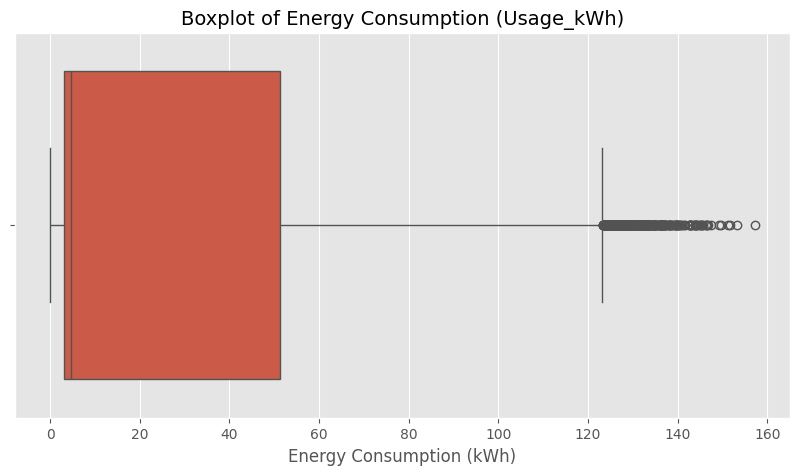

In [40]:
# Boxplot of Outliers
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Usage_kWh'])

plt.title("Boxplot of Energy Consumption (Usage_kWh)", fontsize=14)
plt.xlabel("Energy Consumption (kWh)", fontsize=12)

plt.show()

### Insight

The IQR method identified **328 outliers** in the `Usage_kWh` feature, representing approximately **0.94%** of the dataset. The lower bound is negative, which is expected because energy consumption cannot be less than zero. Therefore, all detected outliers occur above the upper bound, indicating periods of unusually high energy usage. These observations likely correspond to peak production or high-demand operating conditions rather than data entry errors.

## Correlation Analysis

Correlation analysis is performed to measure the strength of the relationship between numerical features. A correlation heatmap provides a visual representation of these relationships and helps identify the variables most strongly associated with energy consumption.

In [41]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Display numerical columns
numerical_df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Month,Power_Factor_Ratio,High_Load
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1,1.365934,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1,1.497679,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1,1.422880,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1,1.468644,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1,1.545117,0


In [42]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Month,Power_Factor_Ratio,High_Load
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,2.346103e-01,2.341748e-01,-1.139607e-01,-0.090094,0.867840
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,8.266237e-02,8.125047e-02,-4.213561e-02,0.075592,0.825672
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,3.716046e-01,3.727349e-01,-2.709951e-02,-0.779884,-0.294913
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,2.317260e-01,2.313063e-01,-1.083105e-01,-0.082349,0.863164
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,5.652695e-01,5.665439e-01,-8.705239e-02,-0.915117,0.285679
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-3.605630e-01,-3.614087e-01,-3.232157e-02,0.805223,0.296275
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000e+00,9.991858e-01,2.297820e-15,-0.530254,0.177164
Hour,0.234175,0.081250,0.372735,0.231306,0.566544,-0.361409,9.991858e-01,1.000000e+00,-6.087321e-16,-0.531380,0.176399
Month,-0.113961,-0.042136,-0.027100,-0.108311,-0.087052,-0.032322,2.297820e-15,-6.087321e-16,1.000000e+00,0.062670,-0.068300
Power_Factor_Ratio,-0.090094,0.075592,-0.779884,-0.082349,-0.915117,0.805223,-5.302543e-01,-5.313801e-01,6.266972e-02,1.000000,-0.056465


## Correlation Heatmap

The correlation matrix is visualized using a heatmap. Darker colors indicate stronger relationships, while lighter colors represent weaker relationships. Positive correlations are shown in warm colors, whereas negative correlations appear in cooler colors.

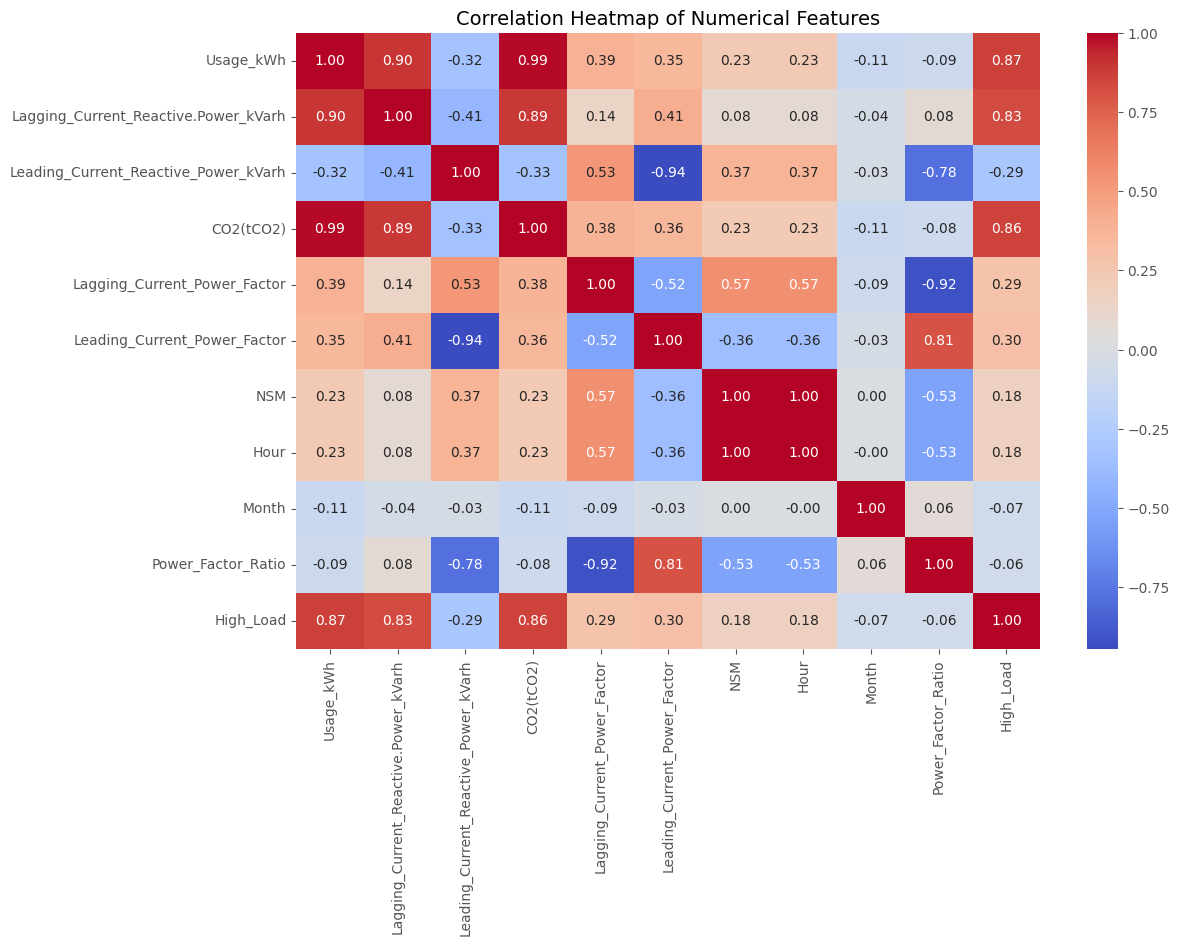

In [43]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)

plt.show()

In [44]:
# TOP 3 FEATURES
top_features = (
    correlation_matrix['Usage_kWh']
    .drop('Usage_kWh')          # Remove self-correlation (which is always 1)
    .abs()                      # Use absolute values to measure strength
    .sort_values(ascending=False)
)

print("Top 3 features most correlated with Usage_kWh:\n")
print(top_features.head(3))

Top 3 features most correlated with Usage_kWh:

CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Load                               0.86784
Name: Usage_kWh, dtype: float64
